Homework 4. Part 2

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore")

rng = np.random.default_rng(5141)

n_treated = 40
n_control = 60
TRUE_ATT = 5.0

rows = []

for i in range(n_treated):
    sid = f"T{i}"
    alpha = rng.normal(12, 2)
    for year, post in [(2023, 0), (2024, 1)]:
        delta_year = 1.5 if post else 0.0
        treat_effect = TRUE_ATT if post else 0.0
        eps = rng.normal(0, 1.2)
        Y = alpha + delta_year + treat_effect + eps
        rows.append({"store_id": sid, "year": year, "treated": 1, "post": post, "Y": Y})

for j in range(n_control):
    sid = f"C{j}"
    alpha = rng.normal(10, 2)
    for year, post in [(2023, 0), (2024, 1)]:
        delta_year = 1.5 if post else 0.0
        eps = rng.normal(0, 1.2)
        Y = alpha + delta_year + eps
        rows.append({"store_id": sid, "year": year, "treated": 0, "post": post, "Y": Y})

df_did = pd.DataFrame(rows)

In [6]:
mean_treated_pre = df_did[(df_did["treated"] == 1) & (df_did["post"] == 0)]["Y"].mean()
mean_treated_post = df_did[(df_did["treated"] == 1) & (df_did["post"] == 1)]["Y"].mean()
mean_control_pre = df_did[(df_did["treated"] == 0) & (df_did["post"] == 0)]["Y"].mean()
mean_control_post = df_did[(df_did["treated"] == 0) & (df_did["post"] == 1)]["Y"].mean()

print("Treated, Pre :", mean_treated_pre)
print("Treated, Post:", mean_treated_post)
print("Control, Pre :", mean_control_pre)
print("Control, Post:", mean_control_post)

Treated, Pre : 11.617075812122014
Treated, Post: 18.572213467022078
Control, Pre : 9.533784405083521
Control, Post: 11.009528435769223


In [8]:
did_manual = (mean_treated_post - mean_treated_pre) - (mean_control_post - mean_control_pre)
print("Manual DID =", did_manual)

Manual DID = 5.479393624214362


In [10]:
df_did["treated_post"] = df_did["treated"] * df_did["post"]

In [12]:
X = df_did[["treated", "post", "treated_post"]]
X = sm.add_constant(X)
y = df_did["Y"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.654
Model:                            OLS   Adj. R-squared:                  0.649
Method:                 Least Squares   F-statistic:                     123.5
Date:                Thu, 09 Apr 2026   Prob (F-statistic):           6.08e-45
Time:                        12:32:51   Log-Likelihood:                -457.57
No. Observations:                 200   AIC:                             923.1
Df Residuals:                     196   BIC:                             936.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            9.5338      0.311     30.662   

In [14]:
print("Interaction coefficient =", model.params["treated_post"])
print("Manual DID =", did_manual)

Interaction coefficient = 5.479393624214357
Manual DID = 5.479393624214362


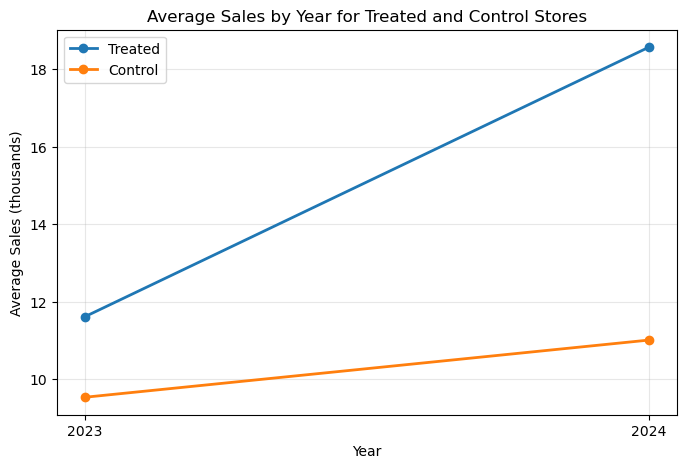

In [16]:
plot_data = df_did.groupby(["year", "treated"])["Y"].mean().reset_index()

treated_line = plot_data[plot_data["treated"] == 1]
control_line = plot_data[plot_data["treated"] == 0]

plt.figure(figsize=(8, 5))
plt.plot(treated_line["year"], treated_line["Y"], marker="o", linewidth=2, label="Treated")
plt.plot(control_line["year"], control_line["Y"], marker="o", linewidth=2, label="Control")
plt.xlabel("Year")
plt.ylabel("Average Sales (thousands)")
plt.title("Average Sales by Year for Treated and Control Stores")
plt.xticks([2023, 2024])
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The plot compares average sales for treated and control stores over time.

The DID assumption is parallel trends: without treatment, treated stores would have followed the same trend as control stores.

With more pre-treatment years, a violation would appear if the two groups had different trends before 2024.